<h2><b>📌 INTRODUCTION</b></h2>

In [ ]:
This project predicts whether a bank customer will subscribe to a term deposit
based on data from a marketing campaign.

The dataset is from the UCI Bank Marketing Repository and includes features
like age, job, duration, previous outcome, and contact month.

# Objectives:
- Load and preprocess the dataset
- Encode all categorical features properly
- Train Logistic Regression and Random Forest models
- Evaluate using accuracy, F1-score, and ROC AUC
- Use LIME to explain at least 5 predictions per model

In [100]:
# STEP 1: Basic libraries
import pandas as pd
import numpy as np

# Explainability
import warnings
warnings.filterwarnings('ignore')

In [6]:
# STEP 2: Load Bank Marketing Dataset from UCI Repository

df = pd.read_csv("bank.csv")

# show info
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [7]:
# Check for nulls
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


<h2><b>Visualization</b></h2>

<h2><b>Barchart</b></h2>

Text(0, 0.5, 'Count')

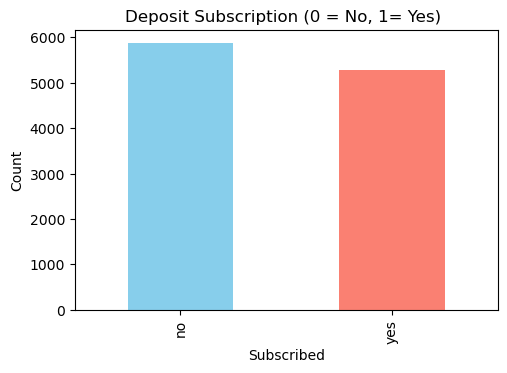

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

df['deposit_num'] = df['deposit'].map({'yes': 1, 'no': 0})

# STEP 3: EDA Visualizations
plt.figure(figsize=(12, 8))

# 1. Target Distribution
plt.subplot(2, 2, 1)
df['deposit'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Deposit Subscription (0 = No, 1= Yes) ')
plt.xlabel('Subscribed')
plt.ylabel('Count')


<h2><b>Histograms</b></h2>

Text(0.5, 1.0, 'Age Distribution')

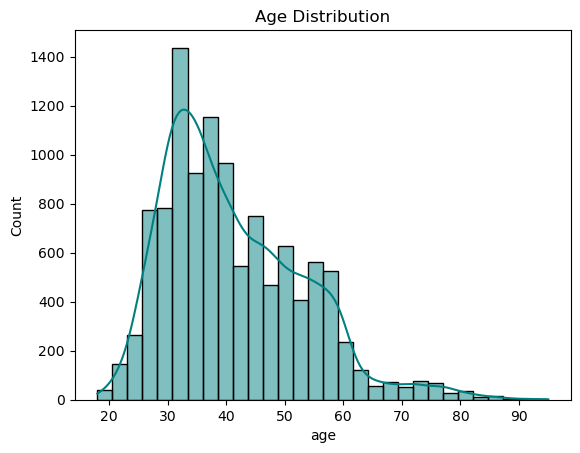

In [15]:
# 2. Age Distribution
plt.subplot(1, 1, 1)
sns.histplot(df['age'], bins=30, kde=True, color='teal')
plt.title('Age Distribution')

(-2000.0, 5000.0)

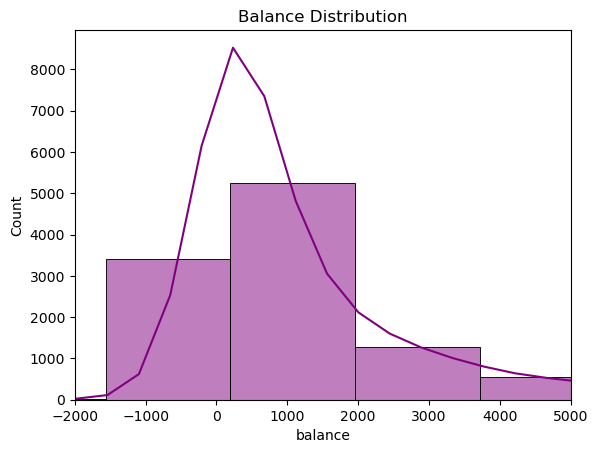

In [17]:
# 3. Balance Distribution
plt.subplot(1, 1, 1)
sns.histplot(df['balance'], bins=50, kde=True, color='purple')
plt.title('Balance Distribution')
plt.xlim(-2000, 5000)


Text(0.5, 1.0, 'Call Duration')

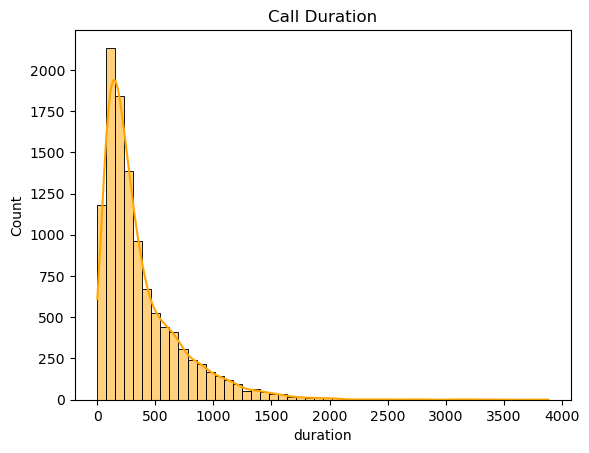

In [20]:
# 4. Duration Distribution
plt.subplot(1, 1, 1)
sns.histplot(df['duration'], bins=50, kde=True, color='orange')
plt.title('Call Duration')


<h2><b> Encoding Features</b></h2>

In [17]:
# STEP 4: Encoding Features
import pandas as pd

# Columns to one-hot encode (multi-class categorical)
cat_cols = ['job', 'marital', 'education', 'contact', 
            'poutcome', 'month']

# Columns with yes/no or True/False
binary_cols = ['deposit', 'housing', 'loan', 'default']

# One-hot encode multi-class categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert all dummy columns (True/False) to 0/1
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

# Convert yes/no columns to 0/1
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0, True: 1, False: 0})

# Save feature names for LIME
target = 'deposit'  
feature_names = [col for col in df_encoded.columns if col != target]

df_encoded.head()
df_encoded.iloc[:, :19].head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student
0,59,0,2343,1,0,5,1042,1,-1,0,1,0,0,0,0,0,0,0,0
1,56,0,45,0,0,5,1467,1,-1,0,1,0,0,0,0,0,0,0,0
2,41,0,1270,1,0,5,1389,1,-1,0,1,0,0,0,0,0,0,0,0
3,55,0,2476,1,0,5,579,1,-1,0,1,0,0,0,0,0,0,1,0
4,54,0,184,0,0,5,673,2,-1,0,1,0,0,0,0,0,0,0,0


<h2><b>Splitting Dataset to Test-Train, Modelling and Evaluation</b></h2>

In [9]:
# STEP 5: Splitting Datasets for Test and Train
from sklearn.model_selection import train_test_split

# Features only: drop target and unwanted columns
X = df_encoded.drop(['deposit'], axis=1, errors='ignore')

# Target: map once, only once
y = df['deposit'].map({'yes': 1, 'no': 0})

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [27]:
# STEP 6: Modelling using Logistic Regression
from sklearn.linear_model import LogisticRegression

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]  # Probability of class 1 ('yes')

import warnings
warnings.filterwarnings('ignore')

Logistic regression Accuracy: 0.830 | F1: 0.819 | ROC AUC: 0.904

              precision    recall  f1-score   support

      No (0)       0.83      0.85      0.84      1175
     Yes (1)       0.83      0.81      0.82      1058

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



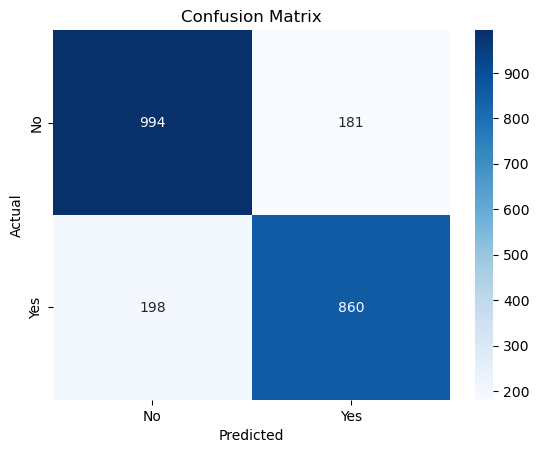

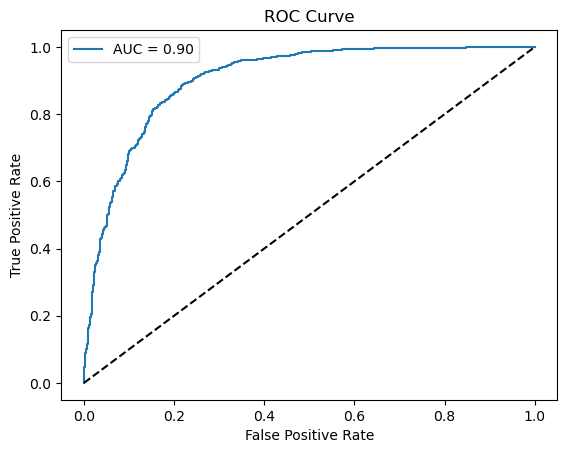

In [116]:
# STEP 7: Logistic Regression Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

model_name = "Logistic regression"

# Logistic Regression Evaluation
print(f"{model_name} Accuracy: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred):.3f} | ROC AUC: {roc_auc_score(y_test, y_proba):.3f}\n")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.2f}'); plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.show()

In [21]:
# STEP 8: Modelling using Random Forest

from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of class 1 ('yes')

Random Forest Accuracy: 0.862 | F1: 0.859 | ROC AUC: 0.920

              precision    recall  f1-score   support

      No (0)       0.89      0.84      0.86      1175
     Yes (1)       0.83      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



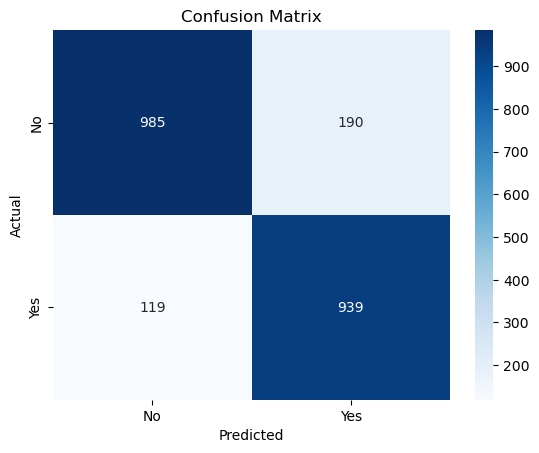

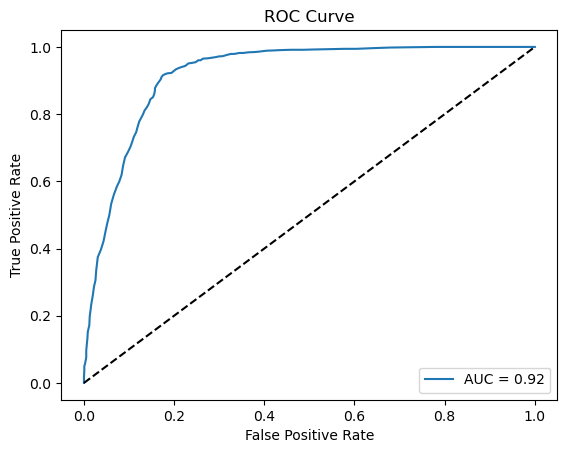

In [22]:
# STEP 9: Random Forest Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

model_name = "Random Forest"

# Random Forest Evaluation
print(f"{model_name} Accuracy: {accuracy_score(y_test, y_pred):.3f} | F1: {f1_score(y_test, y_pred):.3f} | ROC AUC: {roc_auc_score(y_test, y_proba):.3f}\n")
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.2f}'); plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.show()

<h2><b>Using Lime to Explain Model Prediction</b></h2>

<Figure size 800x500 with 0 Axes>

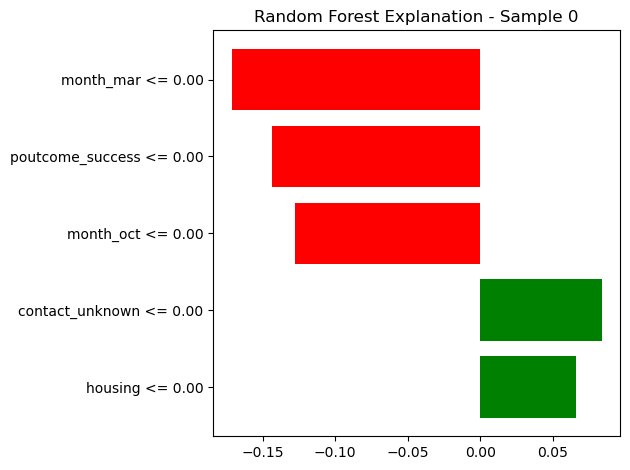


=== Random Forest - Sample 0 ===
True label: No
Predicted probability (Yes): 0.670
Predicted label: Yes
Top features influencing this prediction:
- month_mar <= 0.00: -0.171
- poutcome_success <= 0.00: -0.144
- month_oct <= 0.00: -0.127
- contact_unknown <= 0.00: 0.083
- housing <= 0.00: 0.066



<Figure size 800x500 with 0 Axes>

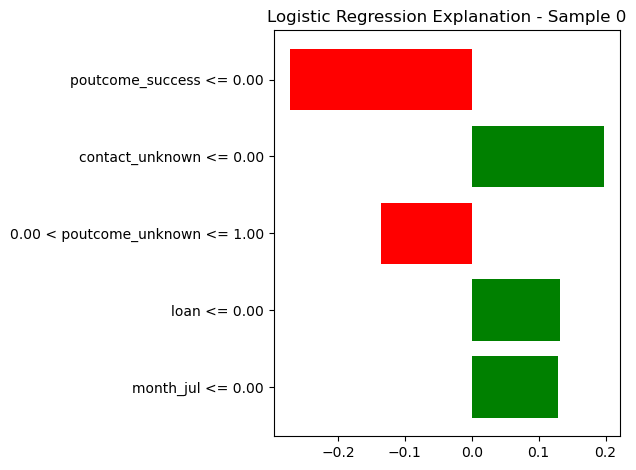


=== Logistic Regression - Sample 0 ===
True label: No
Predicted probability (Yes): 0.684
Predicted label: Yes
Top features influencing this prediction:
- poutcome_success <= 0.00: -0.272
- contact_unknown <= 0.00: 0.198
- 0.00 < poutcome_unknown <= 1.00: -0.136
- loan <= 0.00: 0.131
- month_jul <= 0.00: 0.129



<Figure size 800x500 with 0 Axes>

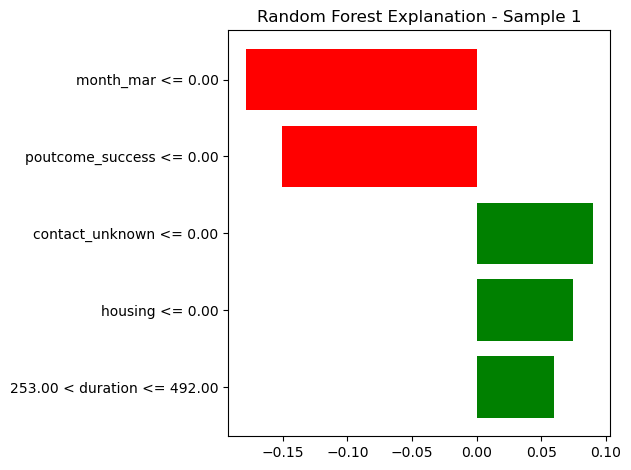


=== Random Forest - Sample 1 ===
True label: Yes
Predicted probability (Yes): 0.690
Predicted label: Yes
Top features influencing this prediction:
- month_mar <= 0.00: -0.179
- poutcome_success <= 0.00: -0.150
- contact_unknown <= 0.00: 0.090
- housing <= 0.00: 0.074
- 253.00 < duration <= 492.00: 0.060



<Figure size 800x500 with 0 Axes>

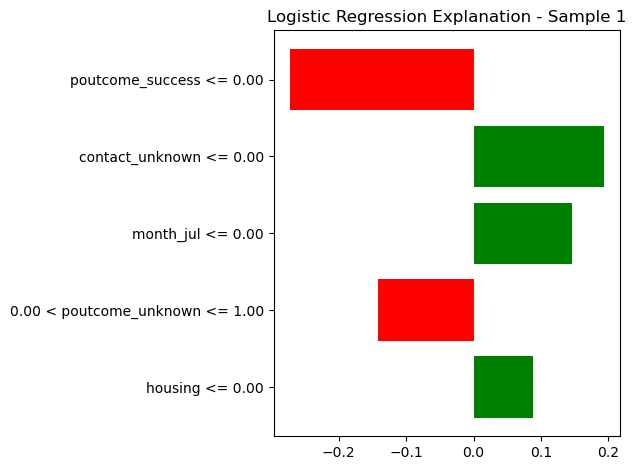


=== Logistic Regression - Sample 1 ===
True label: Yes
Predicted probability (Yes): 0.671
Predicted label: Yes
Top features influencing this prediction:
- poutcome_success <= 0.00: -0.273
- contact_unknown <= 0.00: 0.194
- month_jul <= 0.00: 0.146
- 0.00 < poutcome_unknown <= 1.00: -0.142
- housing <= 0.00: 0.088



<Figure size 800x500 with 0 Axes>

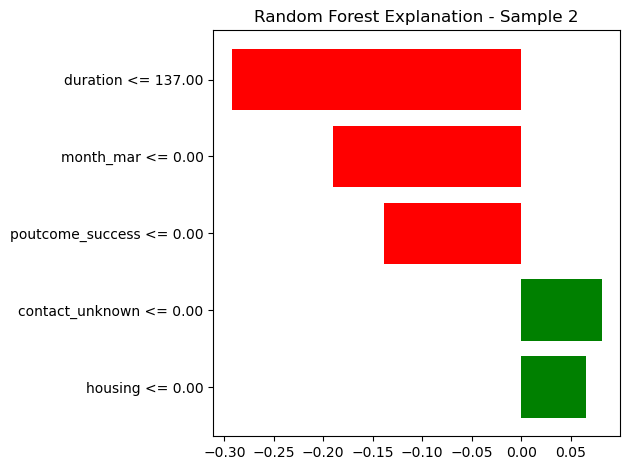


=== Random Forest - Sample 2 ===
True label: No
Predicted probability (Yes): 0.520
Predicted label: Yes
Top features influencing this prediction:
- duration <= 137.00: -0.292
- month_mar <= 0.00: -0.190
- poutcome_success <= 0.00: -0.139
- contact_unknown <= 0.00: 0.081
- housing <= 0.00: 0.066



<Figure size 800x500 with 0 Axes>

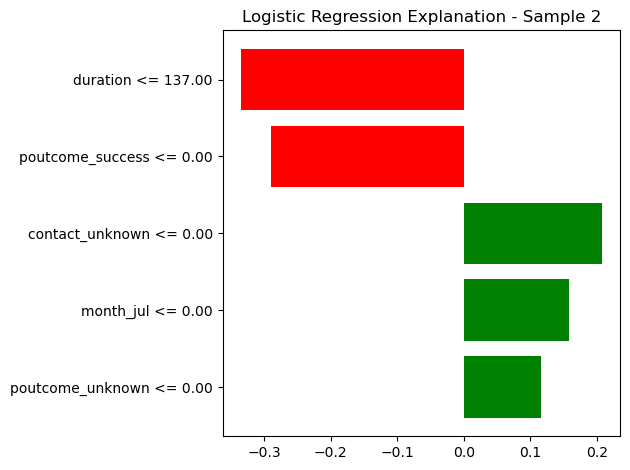


=== Logistic Regression - Sample 2 ===
True label: No
Predicted probability (Yes): 0.637
Predicted label: Yes
Top features influencing this prediction:
- duration <= 137.00: -0.335
- poutcome_success <= 0.00: -0.289
- contact_unknown <= 0.00: 0.208
- month_jul <= 0.00: 0.158
- poutcome_unknown <= 0.00: 0.117



<Figure size 800x500 with 0 Axes>

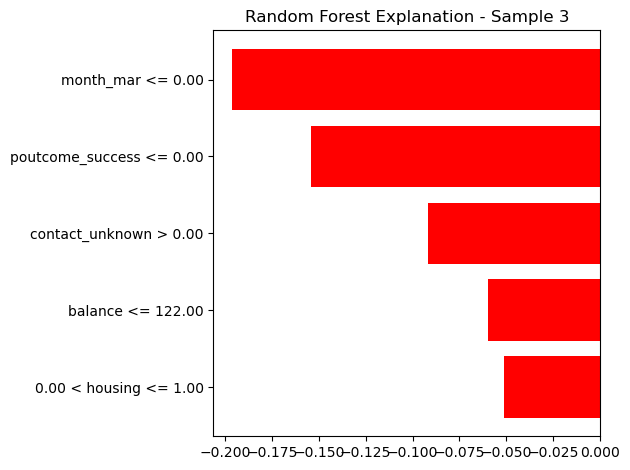


=== Random Forest - Sample 3 ===
True label: No
Predicted probability (Yes): 0.040
Predicted label: No
Top features influencing this prediction:
- month_mar <= 0.00: -0.196
- poutcome_success <= 0.00: -0.154
- contact_unknown > 0.00: -0.092
- balance <= 122.00: -0.060
- 0.00 < housing <= 1.00: -0.051



<Figure size 800x500 with 0 Axes>

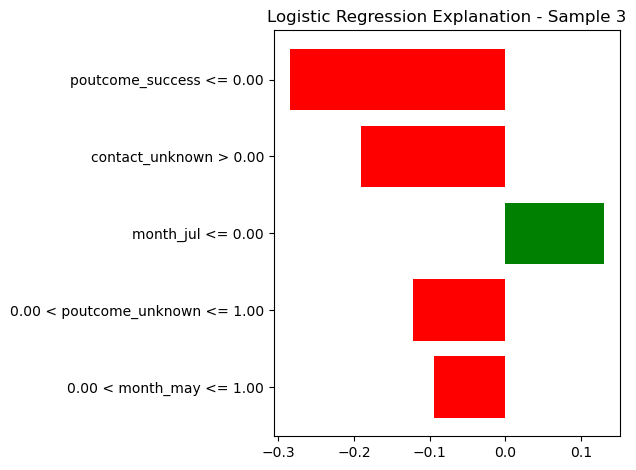


=== Logistic Regression - Sample 3 ===
True label: No
Predicted probability (Yes): 0.071
Predicted label: No
Top features influencing this prediction:
- poutcome_success <= 0.00: -0.285
- contact_unknown > 0.00: -0.190
- month_jul <= 0.00: 0.131
- 0.00 < poutcome_unknown <= 1.00: -0.122
- 0.00 < month_may <= 1.00: -0.095



<Figure size 800x500 with 0 Axes>

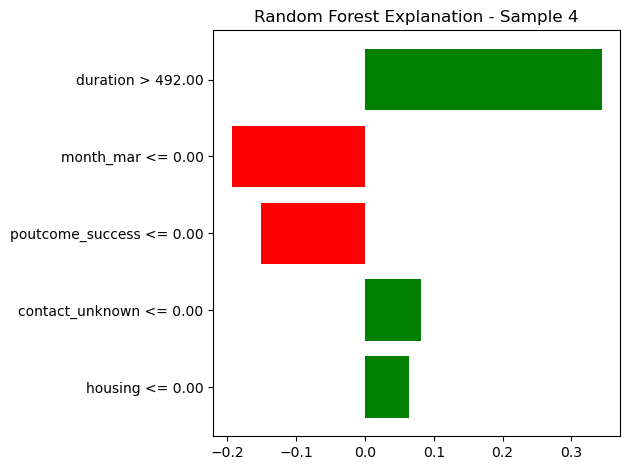


=== Random Forest - Sample 4 ===
True label: Yes
Predicted probability (Yes): 0.760
Predicted label: Yes
Top features influencing this prediction:
- duration > 492.00: 0.344
- month_mar <= 0.00: -0.193
- poutcome_success <= 0.00: -0.151
- contact_unknown <= 0.00: 0.082
- housing <= 0.00: 0.064



<Figure size 800x500 with 0 Axes>

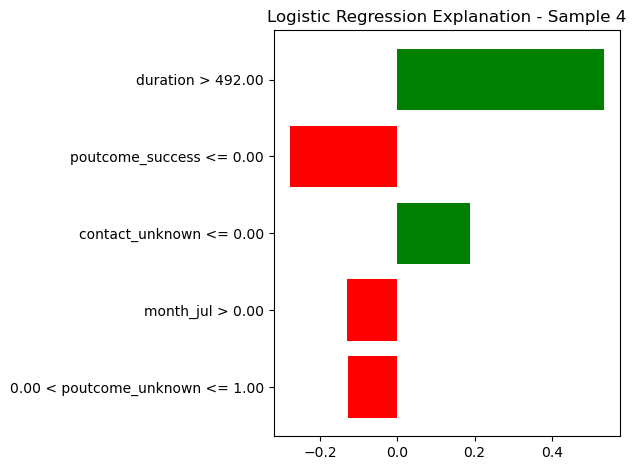


=== Logistic Regression - Sample 4 ===
True label: Yes
Predicted probability (Yes): 0.686
Predicted label: Yes
Top features influencing this prediction:
- duration > 492.00: 0.536
- poutcome_success <= 0.00: -0.279
- contact_unknown <= 0.00: 0.189
- month_jul > 0.00: -0.132
- 0.00 < poutcome_unknown <= 1.00: -0.129



In [28]:
# STEP 10: Explaining Models with Lime
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

# X_train and X_test values
X_train_np = X_train.values
X_test_np = X_test.values

# Feature names from the encoded DataFrame
feature_names = list(X_train.columns)

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    mode='classification',
    discretize_continuous=True
)

# Function to explain a single sample
def explain_sample(model, model_name, sample_index, num_features=5):
    instance = X_test_np[sample_index]
    true_label = y_test.iloc[sample_index] if hasattr(y_test, 'iloc') else y_test[sample_index]
    pred_proba = model.predict_proba(instance.reshape(1, -1))[0]
    pred_label = model.predict(instance.reshape(1, -1))[0]

    # Generate LIME explanation
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=model.predict_proba,
        num_features=num_features
    )

    # Create textual conclusion
    conclusion = f"\n=== {model_name} - Sample {sample_index} ===\n"
    conclusion += f"True label: {'Yes' if true_label else 'No'}\n"
    conclusion += f"Predicted probability (Yes): {pred_proba[1]:.3f}\n"
    conclusion += f"Predicted label: {'Yes' if pred_label else 'No'}\n"
    conclusion += "Top features influencing this prediction:\n"
    for feature, weight in exp.as_list():
        conclusion += f"- {feature}: {weight:.3f}\n"

    # Plot explanation
    plt.figure(figsize=(8,5))
    exp.as_pyplot_figure()
    plt.title(f'{model_name} Explanation - Sample {sample_index}')
    plt.tight_layout()
    plt.show()

    return conclusion


# Example: explain first 5 samples for both models
for i in range(5):
    print(explain_sample(rf, "Random Forest", i))
    print(explain_sample(lr, "Logistic Regression", i))

<h2><b>Final Conclusion</b></h2>

In [ ]:
Model Results:  
- *Logistic Regression:* Accuracy = 0.83, F1-score = 0.82, ROC AUC = 0.90 
- *Random Forest:* Accuracy = 0.86, F1-score = 0.86, ROC AUC = 0.92  

Insights from LIME Explanations:
LIME analysis of 5 predictions per model showed that the most influential features were:  
- Call duration — longer conversations strongly increased the likelihood of subscription  
- Previous campaign outcome — successful past responses led to higher conversion chances  
- Month of contact — timing had a measurable effect on outcomes  
- Customer age — older customers were more likely to subscribe in some cases  

# 🔍 Strategic Suggestions:

1. Deploy Random Forest in production systems due to its superior performance and ability to capture complex patterns in customer behavior.

2. Target high-potential leads by focusing on:
   - Customers with long call durations
   - Those with previously successful campaign interactions

3. Refine campaign timing by launching marketing efforts during months with historically higher response rates.

4. Segment customers by age and interaction history* to personalize messages and improve engagement.

5. Use LIME periodically to audit model decisions, improve transparency, and ensure fairness in targeting strategies.

# Summary:  
Random Forest combined with LIME delivers both predictive power and interpretability. These tools enable data-driven, targeted marketing 
that can increase subscription rates while reducing wasted outreach.